In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\Users\LENOVO\Desktop\E2E-Fraud-Detection\notebooks\Data\AIML Dataset.csv')

In [3]:
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4103673,301,CASH_OUT,136065.69,C1592782251,84756.00,0.00,C638676504,0.00,136065.69,0,0
2410344,202,CASH_IN,227001.47,C1412548467,4156116.04,4383117.52,C866460583,1250381.49,1023380.02,0,0
3144077,236,PAYMENT,1234.61,C6458204,195.00,0.00,M582352404,0.00,0.00,0,0
1454147,140,TRANSFER,40174.42,C745236260,0.00,0.00,C494040824,1058168.16,1098342.58,0,0
980772,44,TRANSFER,1092215.38,C684135813,0.00,0.00,C1088616577,2564343.98,3656559.37,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
df.describe(include='all')

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C2098525306,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [10]:
fraud_counts = df["isFraud"].value_counts()
fraud_pct = df["isFraud"].mean() * 100
fraud_counts

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
fraud_pct

np.float64(0.12908204481801522)

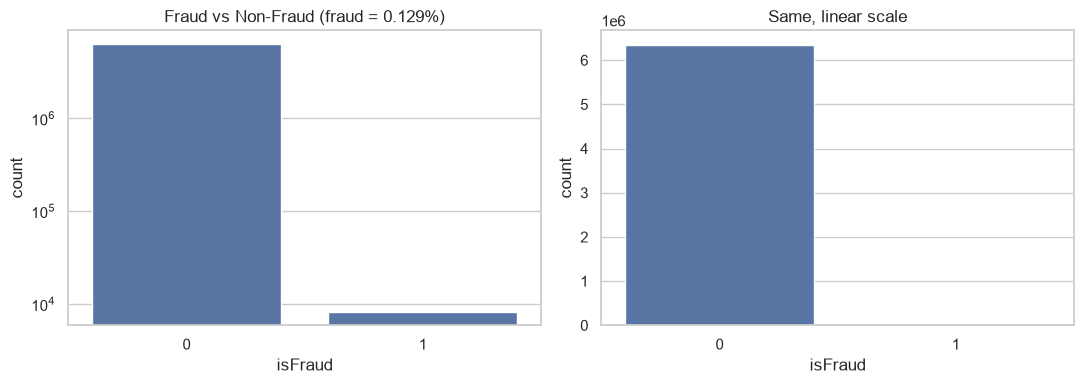

In [12]:

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="isFraud", data=df, ax=ax[0])
ax[0].set_title(f"Fraud vs Non-Fraud (fraud = {fraud_pct:.3f}%)")
ax[0].set_yscale("log")

sns.countplot(x="isFraud", data=df, ax=ax[1])
ax[1].set_title("Same, linear scale")
plt.tight_layout()
plt.show()

In [13]:
fraud_rate_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_rate_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

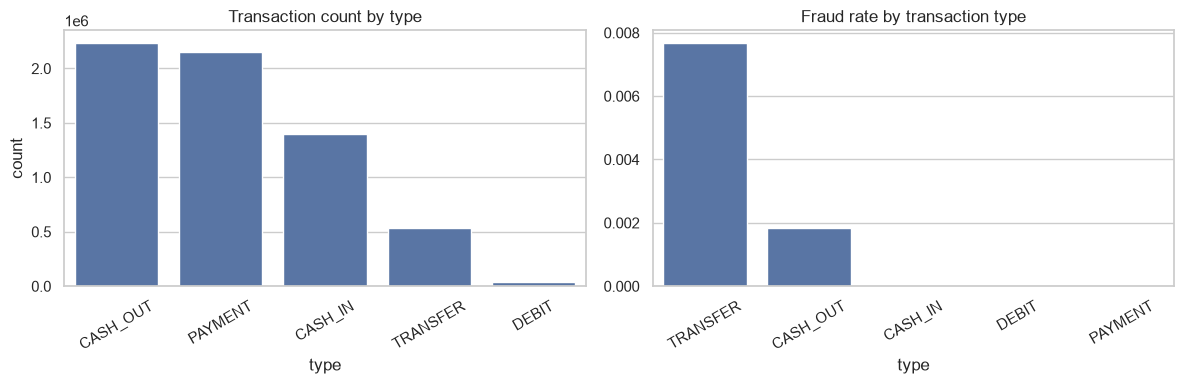

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="type", data=df, order=df["type"].value_counts().index, ax=ax[0])
ax[0].set_title("Transaction count by type")
ax[0].tick_params(axis="x", rotation=30)

sns.barplot(x=fraud_rate_by_type.index, y=fraud_rate_by_type.values, ax=ax[1])
ax[1].set_title("Fraud rate by transaction type")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [15]:
df["amount"].value_counts().sort_index().head(5)

amount
0.00    16
0.01     1
0.02     3
0.03     2
0.04     1
Name: count, dtype: int64

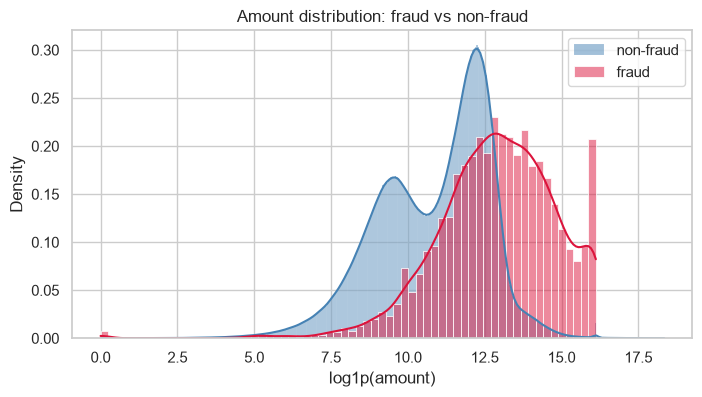

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(np.log1p(df.loc[df.isFraud == 0, "amount"]), color="steelblue", label="non-fraud", stat="density", kde=True, ax=ax)
sns.histplot(np.log1p(df.loc[df.isFraud == 1, "amount"]), color="crimson", label="fraud", stat="density", kde=True, ax=ax)
ax.set_xlabel("log1p(amount)")
ax.set_title("Amount distribution: fraud vs non-fraud")
ax.legend()
plt.show()

In [17]:
df["errorBalanceOrig"] = df["newbalanceOrig"] + df["amount"] - df["oldbalanceOrg"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

In [18]:
df["errorBalanceOrig"]

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
6362615    0.0
6362616    0.0
6362617    0.0
6362618    0.0
6362619    0.0
Name: errorBalanceOrig, Length: 6362620, dtype: float64

In [19]:
df["errorBalanceDest"]

0          9.839640e+03
1          1.864280e+03
2          1.810000e+02
3          2.136300e+04
4          1.166814e+04
               ...     
6362615    0.000000e+00
6362616    6.311409e+06
6362617    1.000000e-02
6362618    8.500025e+05
6362619    9.313226e-10
Name: errorBalanceDest, Length: 6362620, dtype: float64

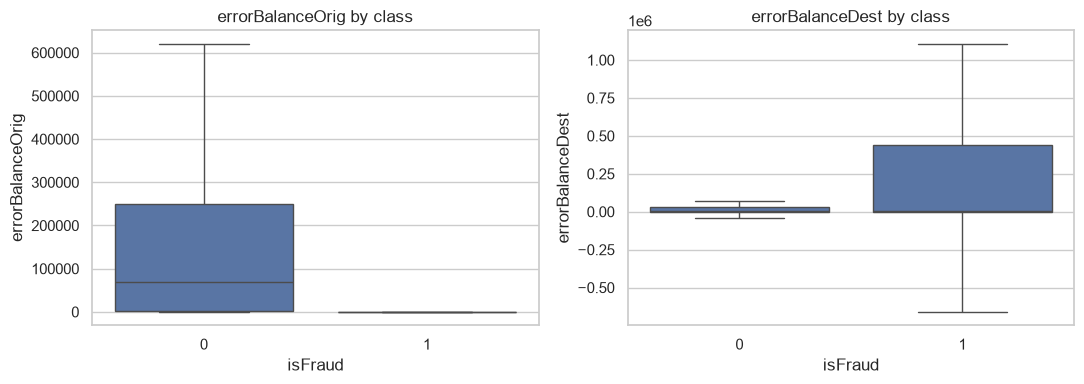

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x="isFraud", y="errorBalanceOrig", data=df, ax=ax[0], showfliers=False)
ax[0].set_title("errorBalanceOrig by class")
sns.boxplot(x="isFraud", y="errorBalanceDest", data=df, ax=ax[1], showfliers=False)
ax[1].set_title("errorBalanceDest by class")
plt.tight_layout()
plt.show()

In [21]:
num_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig",
            "oldbalanceDest", "newbalanceDest", "errorBalanceOrig", "errorBalanceDest", "isFraud"]
df[num_cols].corr()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest,isFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.020516,0.028159,0.031578
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.970660,-0.189928,0.076688
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.050502,0.156464,0.010154
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,0.056897,0.163161,-0.008148
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,0.304256,-0.025460,-0.005885
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.458750,-0.174942,0.000535
errorBalanceOrig,0.020516,0.970660,0.050502,0.056897,0.304256,0.458750,1.000000,-0.147540,-0.011283
errorBalanceDest,0.028159,-0.189928,0.156464,0.163161,-0.025460,-0.174942,-0.147540,1.000000,0.055120
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,-0.011283,0.055120,1.000000


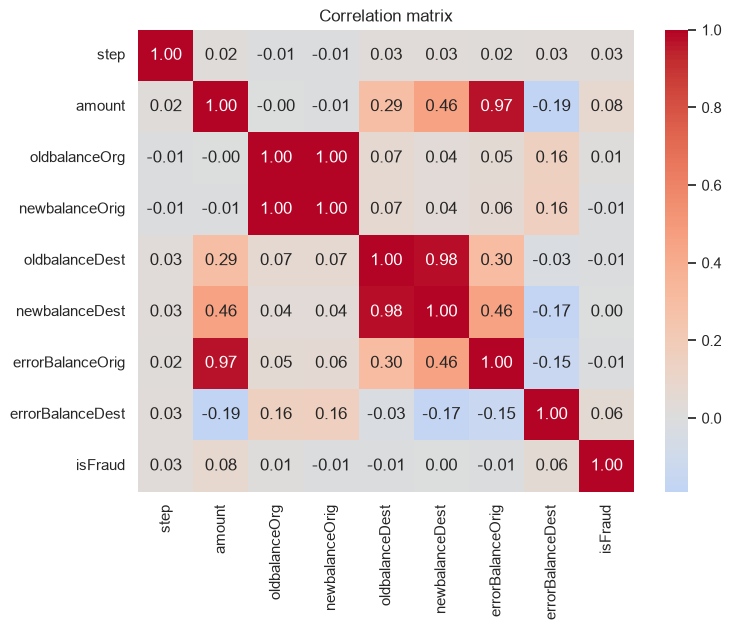

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

In [23]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'errorBalanceOrig', 'errorBalanceDest'],
      dtype='str')

In [24]:
df["step"].value_counts().sample(5)

step
208    29058
266      767
549      642
69        20
328    26877
Name: count, dtype: int64

In [25]:
df["hour"] = df["step"] % 24
df["day"] = df["step"] // 24

In [26]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,hour,day
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64,1,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28,1,0


In [27]:
df.shape

(6362620, 15)

In [28]:
df.to_csv("cleaned_data.csv", index=False)